In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")

df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [8]:
print("Shape:", df.shape)
df.info()
df.describe()


Shape: (5000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [9]:
df.isnull().sum()
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()

In [40]:
(df=="?").sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

In [10]:
df["health_risk"].value_counts()

health_risk
high    3490
low     1510
Name: count, dtype: int64

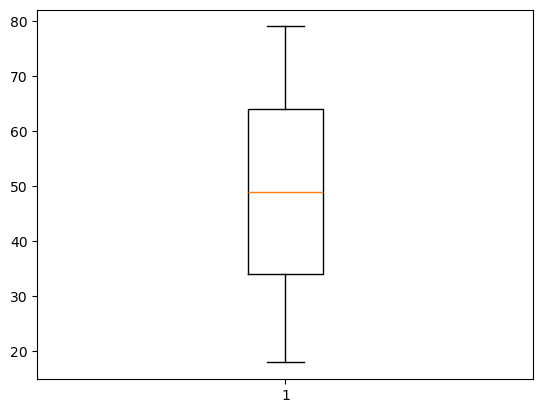

In [17]:
plt.boxplot(df['age'])
plt.show()

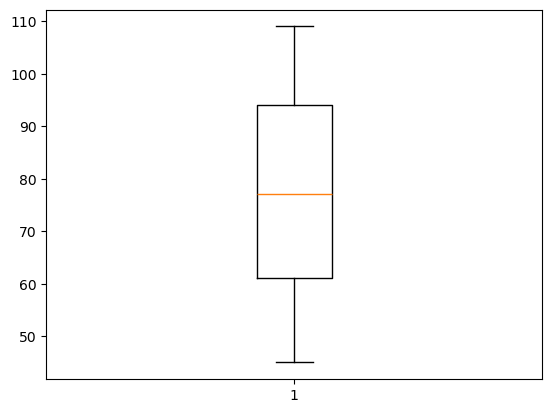

In [18]:
plt.boxplot(df['weight'])
plt.show()

In [11]:
encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,1,6.1,2,1,1,1,5,17.6,0
1,69,76,170,0,6.9,0,0,0,0,7,26.3,0
2,46,106,153,0,6.6,1,1,0,0,0,45.3,0
3,32,54,186,2,8.5,2,0,0,0,0,15.6,1
4,60,98,195,0,8.0,1,0,0,1,7,25.8,0


In [27]:
X = df.drop("health_risk", axis=1)
y = df["health_risk"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 11)
Target shape: (5000,)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, stratify=y)

In [30]:
X

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi
0,56,67,195,1,6.1,2,1,1,1,5,17.6
1,69,76,170,0,6.9,0,0,0,0,7,26.3
2,46,106,153,0,6.6,1,1,0,0,0,45.3
3,32,54,186,2,8.5,2,0,0,0,0,15.6
4,60,98,195,0,8.0,1,0,0,1,7,25.8
...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,2,7.2,1,0,0,1,2,21.4
4996,39,86,183,1,7.4,1,0,0,1,3,25.7
4997,48,56,194,3,7.2,0,1,1,1,3,14.9
4998,34,109,148,2,9.9,2,0,0,1,1,49.8


In [31]:
y

0       0
1       0
2       0
3       1
4       0
       ..
4995    1
4996    0
4997    0
4998    1
4999    1
Name: health_risk, Length: 5000, dtype: int64

In [32]:
X_train

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi
3648,36,87,173,1,8.5,2,0,1,1,3,29.1
1911,54,84,157,1,7.5,1,0,0,0,0,34.1
2404,70,90,167,2,7.2,0,0,0,0,6,32.3
3561,49,69,157,3,6.1,1,1,1,1,1,28.0
1249,20,66,156,1,7.1,1,0,0,0,0,27.1
...,...,...,...,...,...,...,...,...,...,...,...
2069,67,78,152,2,7.8,1,0,1,1,7,33.8
274,56,64,151,3,7.1,2,0,0,0,4,28.1
610,51,69,173,0,8.5,2,0,0,1,1,23.1
2263,56,109,180,2,6.6,2,0,1,0,0,33.6


In [33]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.996


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       698
           1       0.99      0.99      0.99       302

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[696   2]
 [  2 300]]


In [37]:
sample_input = pd.DataFrame([{
    "age": 22,
    "weight": 65,
    "height": 165,
    "exercise": 2,
    "sleep": 6,
    "sugar_intake": 3,
    "smoking": 0,
    "alcohol": 0,
    "married": 0,
    "profession": 1,
    "bmi": 23.9
}])

prediction = model.predict(sample_input)

print("Predicted Health Risk:", prediction[0])

Predicted Health Risk: 1


In [38]:
risk_label = encoders["health_risk"].inverse_transform(prediction)

print("Predicted Health Risk:", risk_label[0])

Predicted Health Risk: low


In [39]:
import pickle

with open("health_risk_model.pkl", "wb") as file:
    pickle.dump({
        "model": model,
        "encoders": encoders,
        "columns": X.columns.tolist()
    }, file)

print("Model saved successfully.")

Model saved successfully.
